# Chapter 12: Simpson's paradox

Make the paradox happen. Watch the aggregate sign flip while every segment stays positive.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from expkit.sim.user_segments import SegmentSpec, imbalanced_assignment
from expkit.plot.style import apply_style, PALETTE
apply_style()

## Loop A: build the toy

Segment A is small (20%) with high baseline (80%). Segment B is large (80%) with low baseline (20%). Treatment lifts each by 5pp.

Then: imbalanced assignment. Treatment is overrepresented in segment B.

In [2]:
specs = [SegmentSpec('A', 0.20, 0.80, 0.05), SegmentSpec('B', 0.80, 0.20, 0.05)]
def show_paradox(treatment_share_a, n_total=20000):
    share = {'A': float(treatment_share_a), 'B': 1.0 - float(treatment_share_a)}
    pop = imbalanced_assignment(n_total, specs, share, seed=1200)
    print(f'Treatment share: A={share["A"]:.2f}, B={share["B"]:.2f}')
    for s in specs:
        c = pop[s.name]['control'].mean(); t = pop[s.name]['treatment'].mean()
        print(f'  segment {s.name}: control={c:.3f}  treatment={t:.3f}  diff = {t-c:+.3f}')
    c_total = np.concatenate([pop[s.name]['control'] for s in specs])
    t_total = np.concatenate([pop[s.name]['treatment'] for s in specs])
    print(f'  AGGREGATE:    control={c_total.mean():.3f}  treatment={t_total.mean():.3f}  diff = {t_total.mean()-c_total.mean():+.3f}')
show_paradox(0.20)  # Imbalanced: paradox triggers

Treatment share: A=0.20, B=0.80
  segment A: control=0.794  treatment=0.851  diff = +0.057
  segment B: control=0.198  treatment=0.249  diff = +0.051
  AGGREGATE:    control=0.496  treatment=0.284  diff = -0.212


In [3]:
show_paradox(0.50)  # Balanced: paradox does NOT trigger; aggregate matches truth

Treatment share: A=0.50, B=0.50
  segment A: control=0.798  treatment=0.846  diff = +0.047
  segment B: control=0.197  treatment=0.254  diff = +0.057
  AGGREGATE:    control=0.317  treatment=0.372  diff = +0.055


## Loop B: when does the sign flip?

Sweep the treatment share in segment A. Watch the aggregate move from -X% (paradox) through 0 to +5% (truth) as assignment becomes balanced.

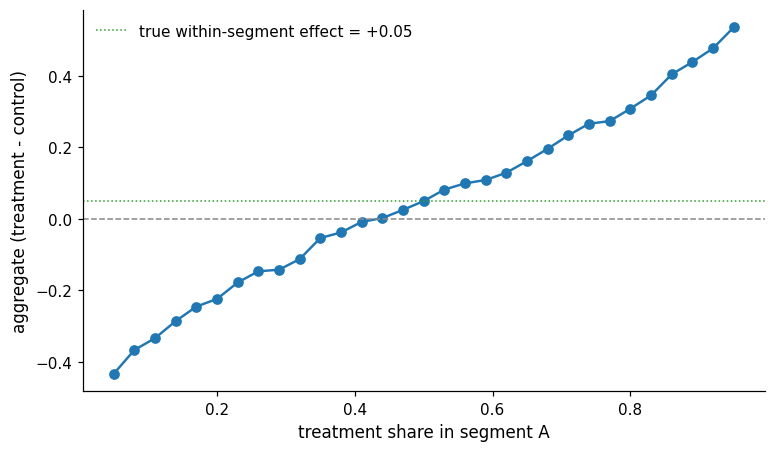

In [4]:
rng = np.random.default_rng(0)
shares = np.linspace(0.05, 0.95, 31)
aggs = []
for s_a in shares:
    pop = imbalanced_assignment(10000, specs, {'A': float(s_a), 'B': 1 - float(s_a)}, seed=int(rng.integers(0, 2**30)))
    c = np.concatenate([pop[sp.name]['control'] for sp in specs])
    t = np.concatenate([pop[sp.name]['treatment'] for sp in specs])
    aggs.append(t.mean() - c.mean())
fig, ax = plt.subplots()
ax.plot(shares, aggs, marker='o')
ax.axhline(0, color=PALETTE['muted'], linestyle='--', linewidth=1)
ax.axhline(0.05, color=PALETTE['highlight'], linestyle=':', linewidth=1, label='true within-segment effect = +0.05')
ax.set_xlabel('treatment share in segment A'); ax.set_ylabel('aggregate (treatment - control)'); ax.legend(); plt.show()

## Loop C: balanced assignment makes the paradox impossible

Run many simulations under balanced and imbalanced assignments. The balanced one always recovers ~+0.05; the imbalanced one is biased.

In [5]:
rng = np.random.default_rng(0)
for label, sa in [('balanced 50/50', 0.5), ('imbalanced 20/80', 0.2)]:
    runs = []
    for _ in range(100):
        share = {'A': sa, 'B': 1 - sa}
        pop = imbalanced_assignment(10000, specs, share, seed=int(rng.integers(0, 2**30)))
        c = np.concatenate([pop[s.name]['control'] for s in specs])
        t = np.concatenate([pop[s.name]['treatment'] for s in specs])
        runs.append(t.mean() - c.mean())
    print(f'{label:<22} mean aggregate = {np.mean(runs):+.4f}   std = {np.std(runs):.4f}')

balanced 50/50         mean aggregate = +0.0514   std = 0.0078
imbalanced 20/80       mean aggregate = -0.2155   std = 0.0097


## Try it yourself

Edit `specs` above to change segment sizes / baselines / lifts. Try making segment A's baseline lower than B's. Try making the lifts unequal. The paradox can also flip when within-segment effects DIFFER (heterogeneous treatment) and assignment correlates with segment.